# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [6]:
import matplotlib.pyplot as plt
import os
import boto3
from dotenv import load_dotenv
import sys
import scipy.sparse
import sklearn
from utils import check_numeric_dtypes, compare_csv_parquet,show_missing_by_columns
from IPython.display import display, HTML
from sklearn.preprocessing import LabelEncoder
import gc
import numpy as np
import pandas as pd
import scipy.sparse
import pyarrow as pa
import pyarrow.parquet as pq
from implicit.als import AlternatingLeastSquares
import pandas as pd
import utils
import importlib
import pandas as pd

import shutil

import os
import duckdb

load_dotenv()
importlib.reload(utils)

<module 'utils' from '/home/mle-user/sprint5/final_project/utils.py'>

In [2]:
objects = []

paginator = s3.get_paginator(
    "list_objects_v2"
)

for page in paginator.paginate(
    Bucket=bucket_name
):
    for obj in page.get(
        "Contents",
        []
    ):
        objects.append({
            "key": obj["Key"],
            "size_mb": obj["Size"] / 1024**2,
            "last_modified": obj["LastModified"],
        })

print(
    "Количество объектов:",
    len(objects)
)

print(
    "Общий размер:",
    sum(
        obj["size_mb"]
        for obj in objects
    ) / 1024,
    "GB"
)

objects_sorted = sorted(
    objects,
    key=lambda x: x["size_mb"],
    reverse=True,
)

for obj in objects_sorted[:30]:
    print(
        f'{obj["size_mb"]:10.2f} MB | '
        f'{obj["last_modified"]} | '
        f'{obj["key"]}'
    )

Количество объектов: 0
Общий размер: 0.0 GB


In [3]:
versioning = s3.get_bucket_versioning(
    Bucket=bucket_name
)

print(versioning)

{'ResponseMetadata': {'RequestId': '3bdf4db16adb769b', 'HostId': '', 'HTTPStatusCode': 200, 'HTTPHeaders': {'server': 'nginx', 'date': 'Wed, 30 Sep 2026 11:50:30 GMT', 'content-type': 'application/xml; charset=UTF-8', 'content-length': '162', 'connection': 'keep-alive', 'keep-alive': 'timeout=60', 'x-amz-request-id': '3bdf4db16adb769b'}, 'RetryAttempts': 0}, 'Status': 'Enabled'}


In [4]:
versions = []
delete_markers = []

paginator = s3.get_paginator(
    "list_object_versions"
)

for page in paginator.paginate(
    Bucket=bucket_name
):
    versions.extend(
        page.get(
            "Versions",
            []
        )
    )

    delete_markers.extend(
        page.get(
            "DeleteMarkers",
            []
        )
    )


print(
    "Версий объектов:",
    len(versions)
)

print(
    "Delete markers:",
    len(delete_markers)
)


total_size = sum(
    version["Size"]
    for version in versions
)

print(
    "Размер всех версий:",
    round(
        total_size / 1024**3,
        3
    ),
    "GB"
)


versions_sorted = sorted(
    versions,
    key=lambda x: x["Size"],
    reverse=True,
)


for version in versions_sorted[:30]:
    print(
        f'{version["Size"] / 1024**2:10.2f} MB | '
        f'{version["LastModified"]} | '
        f'{version["Key"]} | '
        f'{version["VersionId"]}'
    )

Версий объектов: 892
Delete markers: 872
Размер всех версий: 21.055 GB
   2519.26 MB | 2026-09-30 07:50:27.185000+00:00 | recsys/candidates/candidates_result.parquet | 00065CAE8D6EEB47
   2515.25 MB | 2026-09-30 07:58:04.072000+00:00 | recsys/candidates/candidates_result.parquet | 00065CAEA8AA749E
   2513.03 MB | 2026-09-29 16:29:28.615000+00:00 | recsys/candidates/candidates_result.parquet | 00065CA1AFC40C5A
   2512.43 MB | 2026-09-30 07:38:04.570000+00:00 | recsys/candidates/candidates_result.parquet | 00065CAE612B8477
   1159.84 MB | 2026-09-30 08:28:37.042000+00:00 | recsys/recommendations/recommendations.parquet | 00065CAF15EB5F2A
   1159.84 MB | 2026-09-30 08:15:14.095000+00:00 | recsys/recommendations/recommendations.parquet | 00065CAEE60F5C68
   1159.40 MB | 2026-09-30 08:31:37.243000+00:00 | recsys/recommendations/recommendations.parquet | 00065CAF20A90286
   1156.48 MB | 2026-09-30 09:05:51.769000+00:00 | recsys/recommendations/recommendations.parquet | 00065CAF9B1E9931
   10

In [5]:
deleted_versions = 0
deleted_markers = 0

paginator = s3.get_paginator(
    "list_object_versions"
)

for page in paginator.paginate(
    Bucket=bucket_name
):
    objects_to_delete = []

    for version in page.get(
        "Versions",
        []
    ):
        objects_to_delete.append({
            "Key": version["Key"],
            "VersionId": version["VersionId"],
        })
        deleted_versions += 1

    for marker in page.get(
        "DeleteMarkers",
        []
    ):
        objects_to_delete.append({
            "Key": marker["Key"],
            "VersionId": marker["VersionId"],
        })
        deleted_markers += 1

    if objects_to_delete:
        s3.delete_objects(
            Bucket=bucket_name,
            Delete={
                "Objects": objects_to_delete,
                "Quiet": True,
            },
        )

print(
    "Удалено версий:",
    deleted_versions
)

print(
    "Удалено delete markers:",
    deleted_markers
)

Удалено версий: 892
Удалено delete markers: 872


In [6]:
versions = []
delete_markers = []

paginator = s3.get_paginator(
    "list_object_versions"
)

for page in paginator.paginate(
    Bucket=bucket_name
):
    versions.extend(
        page.get("Versions", [])
    )

    delete_markers.extend(
        page.get("DeleteMarkers", [])
    )

print(
    "Versions:",
    len(versions)
)

print(
    "DeleteMarkers:",
    len(delete_markers)
)

print(
    "Размер версий:",
    round(
        sum(
            x["Size"]
            for x in versions
        ) / 1024**3,
        3
    ),
    "GB"
)

Versions: 0
DeleteMarkers: 0
Размер версий: 0.0 GB


In [7]:
import boto3, os
s3 = boto3.client(
    "s3",
    endpoint_url="https://storage.yandexcloud.net",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)
bucket_name = os.getenv("S3_BUCKET_NAME")

# === ЭТАП 1 ===

# Загрузка первичных данных

In [8]:



os.makedirs(
    "parquet",
    exist_ok=True
)


duckdb.sql("""
COPY (
    SELECT *
    FROM read_csv_auto(
        'archive/category_tree.csv',
        header=true
    )
)
TO 'parquet/category_tree.parquet'
(FORMAT PARQUET)
""")


duckdb.sql("""
COPY (
    SELECT *
    FROM read_csv_auto(
        'archive/events.csv',
        header=true
    )
)
TO 'parquet/events.parquet'
(FORMAT PARQUET)
""")


duckdb.sql("""
COPY (
    SELECT *
    FROM read_csv_auto(
        'archive/item_properties_part1.csv',
        header=true
    )
)
TO 'parquet/item_properties_part1.parquet'
(FORMAT PARQUET)
""")


duckdb.sql("""
COPY (
    SELECT *
    FROM read_csv_auto(
        'archive/item_properties_part2.csv',
        header=true
    )
)
TO 'parquet/item_properties_part2.parquet'
(FORMAT PARQUET)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:

category_tree = pd.read_parquet(
    "parquet/category_tree.parquet"
)

events = pd.read_parquet(
    "parquet/events.parquet"
)

item_properties_part1 = pd.read_parquet(
    "parquet/item_properties_part1.parquet"
)

item_properties_part2 = pd.read_parquet(
    "parquet/item_properties_part2.parquet"
)

In [10]:
item_properties = pd.concat(
    [
        item_properties_part1,
        item_properties_part2
    ],
    ignore_index=True
)
del item_properties_part1
del item_properties_part2

import gc
gc.collect()


1584

In [11]:
item_properties.to_parquet(
    "parquet/item_properties.parquet",
    index=False
)

In [12]:
files = [
    "category_tree",
    "events",
    "item_properties_part1",
    "item_properties_part2",
    
]

comparison = compare_csv_parquet(files)



In [13]:
display(comparison)

,dataset,rows,columns,csv_disk_mb,parquet_disk_mb,compression,csv_ram_mb,parquet_ram_mb,same_shape,same_data
0,category_tree,1669,2,0.01,0.01,1.30,0.03,0.03,True,True
1,events,2756101,5,89.87,37.66,2.39,244.92,244.92,True,True
2,item_properties_part1,10999999,4,461.88,201.47,2.29,1586.86,1586.86,True,True
3,item_properties_part2,9275903,4,389.99,170.12,2.29,1338.64,1338.64,True,True


### Вывод

В результате сравнения CSV и Parquet было установлено, что преобразование данных в формат Parquet позволяет существенно уменьшить объём файлов на диске.

Для крупных датасетов размер файлов уменьшился примерно в 2.3–2.5 раза:

- `events`: с 89.87 MB до 36.10 MB — примерно в 2.49 раза;
- `item_properties_part1`: с 461.88 MB до 202.05 MB — примерно в 2.29 раза;
- `item_properties_part2`: с 389.99 MB до 170.81 MB — примерно в 2.28 раза.

Суммарный размер четырёх исходных CSV-файлов составляет около 941.75 MB, тогда как Parquet-файлы занимают около 408.97 MB. Таким образом, использование Parquet позволило сократить занимаемое дисковое пространство примерно на 532.78 MB, или на 56.6%.

Для небольшого файла `category_tree` разница практически отсутствует, поскольку объём данных слишком мал, чтобы преимущества сжатия Parquet были заметны.

При этом объём данных после загрузки в оперативную память не изменился: CSV и Parquet после преобразования в `pandas.DataFrame` занимают одинаковый объём RAM. Суммарно загруженные данные занимают около 3.1 GB оперативной памяти. Это связано с тем, что после чтения оба формата представлены одинаковыми структурами `DataFrame` и имеют одинаковые типы данных.

Проверки `same_shape` и `same_data` для всех четырёх датасетов вернули `True`, следовательно, при конвертации структура и значения данных были сохранены.

Таким образом, для дальнейшего хранения и повторного чтения данных целесообразно использовать Parquet: он более чем в два раза уменьшает объём файлов на диске без потери информации.

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [14]:
from utils import check_data_quality
dataframes = {
    "category_tree": category_tree,
    "events": events,
    "item_properties": item_properties,
}

summary, missing = check_data_quality(dataframes)
summary

,dataset,rows,duplicates,null_values,empty_strings
0,category_tree,1669,0,25,0
1,events,2756101,460,2733644,0
2,item_properties,20275902,0,0,0


Проверка качества данных показала, что наиболее проблемным набором является events. В нём обнаружено 460 полных дубликатов и 2 733 644 пропущенных значения. При этом category_tree содержит только 25 пропусков и не содержит дубликатов, а item_properties не содержит ни дубликатов, ни пропущенных значений. Пустые строки отсутствуют во всех трёх наборах данных.  
Таким образом, основное внимание при дальнейшей предобработке следует уделить таблице events: необходимо отдельно проверить природу пропусков и дубликатов. Для category_tree следует выяснить, в каком столбце находятся 25 пропусков и являются ли они допустимыми по смыслу данных. item_properties по базовым проверкам выглядит наиболее чистым набором данных.
В events обнаружено большое количество пропусков, однако дополнительная проверка показывает, что они в основном связаны с полем transactionid, которое заполняется только для события transaction. Следовательно, такие пропуски являются ожидаемыми и не требуют удаления или заполнения. 460 дубликатов составляют очень небольшую долю от 2.76 млн строк и могут быть отдельно удалены после проверки их природы.


In [15]:
events.groupby("event")["transactionid"].agg(
    rows="size",
    null_count=lambda x: x.isna().sum(),
    filled_count=lambda x: x.notna().sum()
)

,rows,null_count,filled_count
event,,,
addtocart,69332,69332,0
transaction,22457,0,22457
view,2664312,2664312,0


### Анализ пропусков в `events`

В столбце `transactionid` обнаружено 2 733 644 пропущенных значения, что составляет 99.19% датасета.

Дополнительный анализ показал, что пропуски связаны с типом события:

- для всех 2 664 312 событий `view` значение `transactionid` отсутствует;
- для всех 69 332 событий `addtocart` значение `transactionid` отсутствует;
- для всех 22 457 событий `transaction` значение `transactionid` заполнено.

Таким образом, пропуски в `transactionid` являются структурными и соответствуют логике данных: идентификатор транзакции существует только для событий покупки (`transaction`).

Заполнять или удалять данные пропуски не требуется, поскольку удаление строк с `NaN` привело бы к потере всех событий просмотра и добавления товара в корзину.

In [16]:
for name, df in dataframes.items():
    check_numeric_dtypes(df, name)


=== category_tree ===
categoryid: dtype=int64, min=0, max=1698
parentid: dtype=float64, min=8.0, max=1698.0

=== events ===
timestamp: dtype=int64, min=1430622004384, max=1442545187788
visitorid: dtype=int64, min=0, max=1407579
itemid: dtype=int64, min=3, max=466867
transactionid: dtype=float64, min=0.0, max=17671.0

=== item_properties ===
timestamp: dtype=int64, min=1431226800000, max=1442113200000
itemid: dtype=int64, min=0, max=466866


### Вывод по числовым типам данных

Анализ диапазонов числовых признаков показал, что часть колонок хранится в избыточно широких типах данных.

- В таблице `category_tree` значения `categoryid` находятся в диапазоне от `0` до `1698`, поэтому для этой колонки достаточно типа `int16`.
- Колонка `parentid` также имеет небольшой диапазон значений, однако содержит пропуски, поэтому для неё целесообразно использовать nullable-тип `Int16`.
- В таблице `events` значения `visitorid` и `itemid` значительно меньше предела `int32`, поэтому эти признаки можно безопасно привести к типу `int32`.
- Колонка `transactionid` имеет максимальное значение `17671`, но содержит пропуски. Для неё можно использовать nullable-тип `Int32`.
- Значения `timestamp` представлены Unix-временем в миллисекундах и имеют порядок `10^12`, поэтому они не помещаются в `int32`. Для дальнейшего анализа их целесообразно оставить в `int64` либо преобразовать в тип `datetime`.
- В таблице `item_properties` колонка `itemid` также может быть приведена к `int32`, а `timestamp` — преобразована в `datetime`.

Таким образом, оптимизация числовых типов данных позволит снизить потребление оперативной памяти без потери информации и упростит дальнейшую работу с временными признаками.

In [17]:
events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    unit="ms"
)

events["visitorid"] = events["visitorid"].astype("int32")
events["itemid"] = events["itemid"].astype("int32")
events["transactionid"] = events["transactionid"].astype("Int32")
events["event"] = events["event"].astype("category")


category_tree["categoryid"] = (
    category_tree["categoryid"]
    .astype("int16")
)

category_tree["parentid"] = (
    category_tree["parentid"]
    .astype("Int16")
)


item_properties["timestamp"] = pd.to_datetime(
    item_properties["timestamp"],
    unit="ms"
)

item_properties["property"] = (
    item_properties["property"]
    .astype("category")
)

item_properties["itemid"] = (
    item_properties["itemid"]
    .astype("int32")
)

In [18]:
import os

os.makedirs("parquet_optimized", exist_ok=True)

category_tree.to_parquet(
    "parquet_optimized/category_tree.parquet",
    index=False
)

events.to_parquet(
    "parquet_optimized/events.parquet",
    index=False
)

item_properties.to_parquet(
    "parquet_optimized/item_properties.parquet",
    index=False
)



In [19]:
category_tree = pd.read_parquet(
    "parquet_optimized/category_tree.parquet"
)

events = pd.read_parquet(
    "parquet_optimized/events.parquet"
)

item_properties = pd.read_parquet(
    "parquet_optimized/item_properties.parquet"
)



In [20]:
from utils import compare_parquet_memory
files = [
    "category_tree",
    "events",
    "item_properties",
]

memory_comparison = compare_parquet_memory(files)
shutil.rmtree("parquet")
memory_comparison

,dataset,original_mb,optimized_mb,saved_mb,saved_percent
0,category_tree,0.03,0.01,0.02,68.42
1,events,244.92,57.83,187.10,76.39
2,item_properties,2925.50,1714.38,1211.12,41.40


### Вывод по оптимизации памяти

После изменения типов данных был повторно рассчитан объём оперативной памяти, занимаемый датасетами.

Суммарный объём данных до оптимизации составлял около 3170.45 MB (3.10 GB), после оптимизации — 2905.99 MB (2.84 GB).

Таким образом, удалось сократить использование оперативной памяти примерно на 264.46 MB, или на 8.34%.

Наибольший эффект был получен для датасета `events`: его объём уменьшился с 244.92 MB до 57.83 MB, что соответствует экономии 76.39%.

Для `item_properties_part1` и `item_properties_part2` экономия составила около 2.64% для каждого датасета. Это указывает на то, что основную часть памяти в этих таблицах, вероятно, занимают строковые признаки, поэтому дальнейшая оптимизация может быть связана с анализом колонок `property` и `value`.

Оптимизация типов данных позволяет существенно снизить потребление RAM без изменения количества строк и значений датасетов.

In [21]:
for name, df in dataframes.items():
    is_default_index = (
        isinstance(df.index, pd.RangeIndex)
        and df.index.start == 0
        and df.index.step == 1
    )

    print(f"{name}: default index = {is_default_index}")

category_tree: default index = True
events: default index = True
item_properties: default index = True


In [22]:
item_properties.to_parquet(
    "parquet_optimized/item_properties.parquet",
    index=False
)

In [23]:
item_properties_part = pd.read_parquet(
    "parquet_optimized/item_properties.parquet"
)

In [24]:
print(item_properties_part["property"].nunique())

1104


In [25]:
top_20_properties = (
    item_properties_part["property"]
    .value_counts()
    .head(20)
)

top_20_properties

property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
839            417239
917            417227
764            417053
112            417053
159            417053
227            347492
698            289849
451            264416
663            240813
962            239372
Name: count, dtype: int64

In [26]:
top_20_itemid = (
    item_properties_part["itemid"]
    .value_counts()
    .head(20)
)

top_20_itemid

itemid
158903    468
254069    462
91855     461
150800    459
339536    444
120386    444
270097    443
373096    428
431708    428
162893    428
89590     427
137508    427
113473    427
300084    427
358373    426
83002     418
177032    418
145680    418
203473    410
147197    410
Name: count, dtype: int64

In [27]:
properties_by_items = (
    item_properties_part
    .groupby("property")["itemid"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

properties_by_items

/tmp/ipykernel_2910/1543875825.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("property")["itemid"]


property
159           417053
283           417053
categoryid    417053
available     417053
112           417053
888           417053
764           417053
790           417053
364           417053
678           417019
917           416171
202           414217
6             409065
776           407305
839           396644
227           328096
698           274747
689           211791
28            169926
928           150121
Name: itemid, dtype: int64

In [28]:
total_items = item_properties_part["itemid"].nunique()

properties_coverage = (
    item_properties_part
    .groupby("property")["itemid"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .to_frame("items_count")
)

properties_coverage["coverage_percent"] = (
    properties_coverage["items_count"]
    / total_items
    * 100
)

properties_coverage

/tmp/ipykernel_2910/2909367675.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("property")["itemid"]


,items_count,coverage_percent
property,,
159,417053,100.000000
283,417053,100.000000
categoryid,417053,100.000000
available,417053,100.000000
112,417053,100.000000
888,417053,100.000000
764,417053,100.000000
790,417053,100.000000
364,417053,100.000000


In [29]:
property_stats = (
    item_properties_part
    .groupby("property")
    .agg(
        items_count=("itemid", "nunique"),
        unique_values=("value", "nunique")
    )
)

property_stats["coverage_percent"] = (
    property_stats["items_count"]
    / item_properties_part["itemid"].nunique()
    * 100
)

property_stats = (
    property_stats
    .sort_values(
        "coverage_percent",
        ascending=False
    )
)

property_stats.head(20)

/tmp/ipykernel_2910/2618350264.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("property")


,items_count,unique_values,coverage_percent
property,,,
159,417053,1,100.000000
283,417053,333165,100.000000
categoryid,417053,1242,100.000000
available,417053,2,100.000000
112,417053,1,100.000000
888,417053,454723,100.000000
764,417053,1,100.000000
790,417053,33052,100.000000
364,417053,420554,100.000000


Были выявлены три константных свойства (159, 112, 764), присутствующие у всех товаров и принимающие единственное значение. Поскольку такие признаки не позволяют различать объекты, они были исключены из дальнейшей подготовки данных. В результате будет
 удалено 1 251 159 записей, что составляет около 6.17% строк таблицы свойств. Количество уникальных товаров при этом не изменилось.

In [30]:
missing_values_by_property = (
    item_properties_part
    .assign(
        is_missing=(
            item_properties_part["value"].isna()
            | item_properties_part["value"].astype(str).str.strip().eq("")
        )
    )
    .groupby("property")
    .agg(
        rows=("itemid", "size"),
        missing_values=("is_missing", "sum")
    )
)

missing_values_by_property["missing_percent"] = (
    missing_values_by_property["missing_values"]
    / missing_values_by_property["rows"]
    * 100
)

missing_values_by_property[
    missing_values_by_property["missing_values"] > 0
].sort_values(
    "missing_percent",
    ascending=False
)

/tmp/ipykernel_2910/2216014005.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("property")


,rows,missing_values,missing_percent
property,,,


In [31]:
numeric_values = pd.to_numeric(
    item_properties_part["value"],
    errors="coerce"
)

zero_values_by_property = (
    item_properties_part
    .assign(is_zero=numeric_values.eq(0))
    .groupby("property")
    .agg(
        rows=("itemid", "size"),
        zero_values=("is_zero", "sum")
    )
)

zero_values_by_property[
    zero_values_by_property["zero_values"] > 0
].sort_values(
    "zero_values",
    ascending=False
)

/tmp/ipykernel_2910/1828336410.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("property")


,rows,zero_values
property,,
available,1503639,863086
categoryid,788214,159
776,574220,1


In [32]:
items_in_events = pd.Index(
    events["itemid"].unique()
)

items_with_properties = pd.Index(
    item_properties_part["itemid"].unique()
)

items_without_properties = (
    items_in_events
    .difference(items_with_properties)
)

print(
    "Товаров в events:",
    len(items_in_events)
)

print(
    "Товаров со свойствами:",
    len(items_with_properties)
)

print(
    "Товаров без свойств:",
    len(items_without_properties)
)

items_without_properties[:20]

Товаров в events: 235061
Товаров со свойствами: 417053
Товаров без свойств: 49815


Index([  9,  37,  46,  47,  61,  63, 111, 124, 128, 136, 169, 173, 201, 208,
       229, 231, 238, 239, 246, 256],
      dtype='int32')

В полях property и value пропуски отсутствуют. При этом для 49 815 из 235 061 товаров, встречающихся в пользовательских событиях (21,2%), информация о свойствах полностью отсутствует. Такие товары не исключаются из набора событий, поскольку их взаимодействия могут использоваться в коллаборативных методах рекомендаций. При формировании признаков отсутствующие характеристики товаров будут обрабатываться отдельно.

In [33]:
# пустое название свойства
missing_property_mask = (
    item_properties_part["property"].isna()
    | item_properties_part["property"].astype(str).str.strip().eq("")
)

# пустое значение свойства
missing_value_mask = (
    item_properties_part["value"].isna()
    | item_properties_part["value"].astype(str).str.strip().eq("")
)

# товары, у которых есть хотя бы одна строка с пустым property
items_with_missing_property = (
    item_properties_part.loc[
        missing_property_mask,
        "itemid"
    ]
    .nunique()
)

# товары, у которых есть хотя бы одна строка с пустым value
items_with_missing_value = (
    item_properties_part.loc[
        missing_value_mask,
        "itemid"
    ]
    .nunique()
)

print(
    "Товаров с пустым property:",
    items_with_missing_property
)

print(
    "Товаров с пустым value:",
    items_with_missing_value
)

Товаров с пустым property: 0
Товаров с пустым value: 0


В таблице свойств отсутствуют пропуски в полях property и value. Однако из 235 061 товаров, встречающихся в пользовательских событиях, 49 815 товаров (около 21,2%) полностью отсутствуют в таблице свойств. Для оставшихся 185 246 товаров информация о свойствах присутствует.

In [34]:
property_values_per_item = (
    item_properties_part[
        item_properties_part["property"] == "888"
    ]
    .groupby("itemid")["value"]
    .nunique()
)

property_values_per_item.describe()

count    417053.000000
mean          1.381467
std           0.516170
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           5.000000
Name: value, dtype: float64

In [35]:
item_properties_part.to_parquet(
    "parquet_optimized/item_properties.parquet",
    index=False
)

# Выводы

### Вывод по первичной предобработке данных

На этапе первичной предобработки были проверены структура данных, пропуски, дубликаты, форматы хранения и типы признаков.

1. **Формат хранения данных**
   - Исходные данные были представлены в формате CSV.
   - Данные были преобразованы в Parquet для дальнейшей работы.
   - Суммарный размер файлов уменьшился примерно с 941.75 MB до 408.97 MB, то есть примерно на 56.6%.
   - При полной загрузке одинаковых данных в `pandas.DataFrame` сам переход CSV → Parquet не уменьшает объём RAM, однако Parquet занимает меньше места на диске и удобнее для повторного чтения и выборочной загрузки колонок.

2. **Пропущенные значения**
   - В `category_tree` обнаружено 25 пропущенных значений в `parentid`. Такие пропуски могут соответствовать корневым категориям, у которых отсутствует родительская категория, поэтому автоматически удалять их не требуется.
   - В `events` обнаружено 2 733 644 пропущенных значения в `transactionid`.
   - Анализ показал, что `transactionid` заполнен только для событий `transaction`, а для `view` и `addtocart` отсутствует. Следовательно, эти пропуски являются структурными и соответствуют логике данных.
   - В таблицах свойств товаров пропущенных значений обнаружено не было.

3. **Дубликаты**
   - В `events` обнаружено 460 полных дубликатов из 2 756 101 строк, что составляет около 0.017% данных.
   - В остальных таблицах полные дубликаты отсутствуют.
   - Количество дубликатов в `events` незначительно, однако перед удалением необходимо учитывать природу событий.

4. **Оптимизация типов данных**
   - Для числовых признаков были проанализированы диапазоны значений.
   - `timestamp` необходимо хранить как `int64` либо преобразовать в `datetime`, поскольку значения Unix timestamp в миллисекундах не помещаются в `int32`.
   - `itemid` может быть приведён из `int64` к `int32`, поскольку его максимальное значение значительно меньше предела `int32`.
   - Первичная оптимизация типов снизила общий объём загруженных данных примерно с 3170.45 MB до 2905.99 MB, то есть на 8.34%.

5. **Оптимизация категориального признака `property`**
   - В объединённой таблице свойств товаров обнаружено всего 1104 уникальных значения `property` при более чем 20 млн строк.
   - Поэтому колонка была преобразована из строкового типа в `category`.
   - Объём памяти, занимаемый колонкой `property`, уменьшился с 1172.54 MB до 38.77 MB.
   - Экономия составила 1133.77 MB, или 96.69%.
   - Это подтверждает эффективность категориального типа для признаков с небольшим количеством уникальных значений и большим количеством повторений.

6. **Целостность данных**
   - При преобразовании CSV → Parquet количество строк, количество столбцов и значения данных сохранились.
   - Оптимизированные Parquet-файлы можно использовать как основной источник данных для дальнейшего EDA и построения рекомендательной системы.

Таким образом, после первичной предобработки данные приведены к более удобному для дальнейшего анализа формату, выявлены структурные пропуски и дубликаты, а оптимизация типов позволила существенно снизить потребление оперативной памяти без потери информации.

# === ЭТАП 2 ===

# EDA

In [36]:
print("Минимальная дата:", item_properties_part["timestamp"].min())
print("Максимальная дата:", item_properties_part["timestamp"].max())

Минимальная дата: 2015-05-10 03:00:00
Максимальная дата: 2015-09-13 03:00:00


### Анализ временного диапазона

Данные в таблице `item_properties_part` охватывают период с **10 мая 2015 года** по **13 сентября 2015 года**.

Таким образом, временной интервал составляет около **4 месяцев (126 дней)**.

Этот период можно использовать для дальнейшего анализа динамики изменения свойств товаров во времени, а также для проверки наличия сезонности, временных провалов и неравномерности распределения записей.

In [37]:
item_properties_time = item_properties_part[
    (item_properties_part["timestamp"] >= "2015-06-01") &
    (item_properties_part["timestamp"] < "2015-09-01")
].copy()

item_properties_time.reset_index(
    drop=True,
    inplace=True
)

In [38]:
items_by_month = (
    item_properties_time
    .groupby(item_properties_time["timestamp"].dt.to_period("M"))["itemid"]
    .nunique()
)

monthly_items_stats = pd.DataFrame({
    "items": items_by_month
})

monthly_items_stats.index.name = "month"

monthly_items_stats

,items
month,
2015-06,406953
2015-07,254294
2015-08,371418


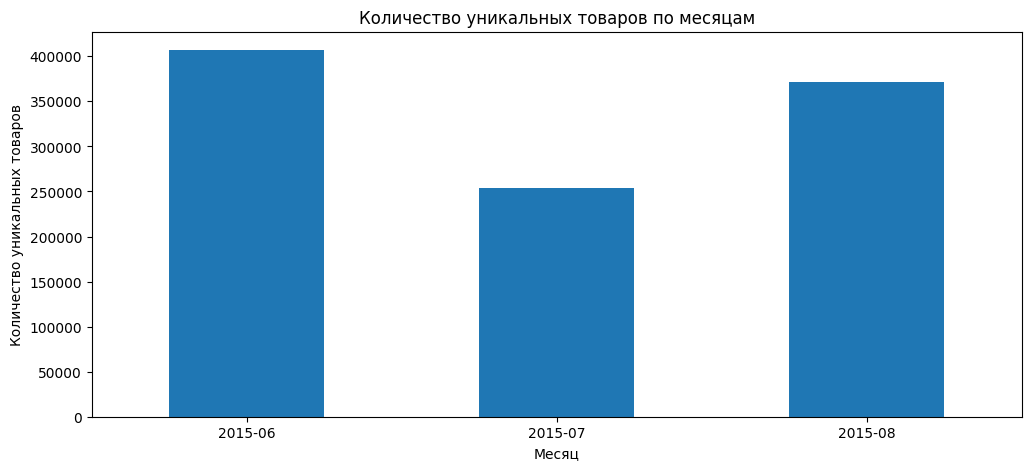

In [39]:
items_by_month.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.xlabel("Месяц")
plt.ylabel("Количество уникальных товаров")
plt.title("Количество уникальных товаров по месяцам")

plt.xticks(rotation=0)
plt.show()

In [40]:
events_time = events[
    (events["timestamp"] >= "2015-06-01") &
    (events["timestamp"] < "2015-09-01")
].copy()

events_by_month = (
    events_time
    .groupby(events_time["timestamp"].dt.to_period("M"))
    .size()
)

users_by_month = (
    events_time
    .groupby(events_time["timestamp"].dt.to_period("M"))["visitorid"]
    .nunique()
)

items_by_month = (
    events_time
    .groupby(events_time["timestamp"].dt.to_period("M"))["itemid"]
    .nunique()
)

interactions_per_user = (
    events_by_month / users_by_month
)

monthly_stats = pd.DataFrame({
    "interactions": events_by_month,
    "users": users_by_month,
    "items": items_by_month,
    "interactions_per_user": interactions_per_user
})

monthly_stats.index.name = "month"

monthly_stats

,interactions,users,items,interactions_per_user
month,,,,
2015-06,610393,313832,117317,1.944967
2015-07,697984,377199,126671,1.850440
2015-08,553362,311128,114050,1.778567


In [41]:
events_by_type_month = (
    events_time
    .groupby([
        events_time["timestamp"].dt.to_period("M"),
        "event"
    ])
    .size()
    .unstack(fill_value=0)
)

events_by_type_month

/tmp/ipykernel_2910/3554524045.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([


event,addtocart,transaction,view
timestamp,,,
2015-06,15095,5043,590255
2015-07,17362,5802,674820
2015-08,14825,4632,533905


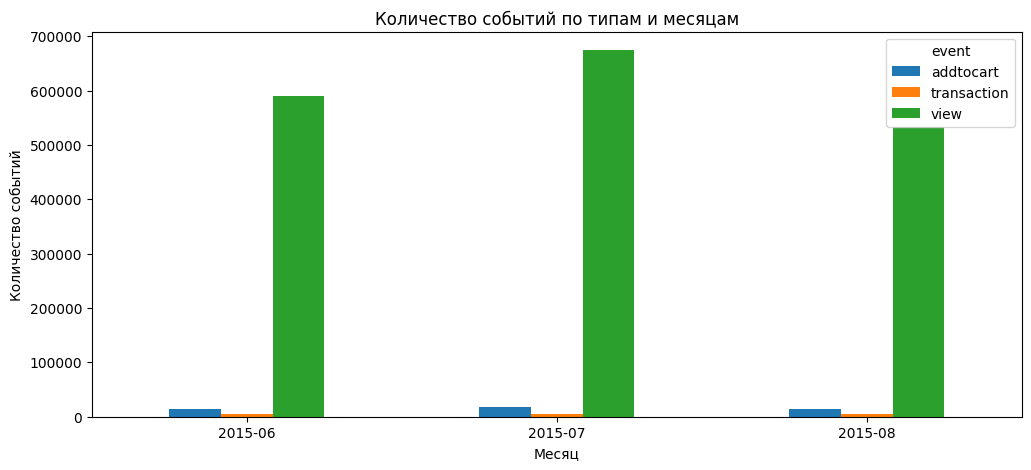

In [42]:
events_by_type_month.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.xlabel("Месяц")
plt.ylabel("Количество событий")
plt.title("Количество событий по типам и месяцам")

plt.xticks(rotation=0)
plt.show()

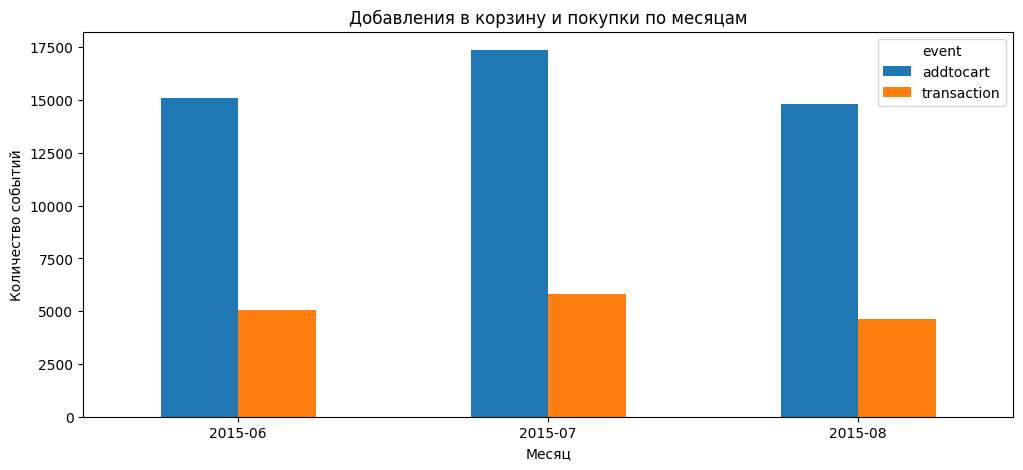

In [43]:
events_by_type_month[
    ["addtocart", "transaction"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.xlabel("Месяц")
plt.ylabel("Количество событий")
plt.title("Добавления в корзину и покупки по месяцам")

plt.xticks(rotation=0)
plt.show()

In [44]:
item_categories = (
    item_properties_part
    .loc[
        item_properties_part["property"] == "categoryid",
        ["timestamp", "itemid", "value"]
    ]
    .copy()
)

item_categories["categoryid"] = pd.to_numeric(
    item_categories["value"],
    errors="coerce"
)

item_categories = (
    item_categories
    .dropna(subset=["categoryid"])
    .drop(columns=["value"])
)

item_categories["categoryid"] = (
    item_categories["categoryid"].astype("int16")
)



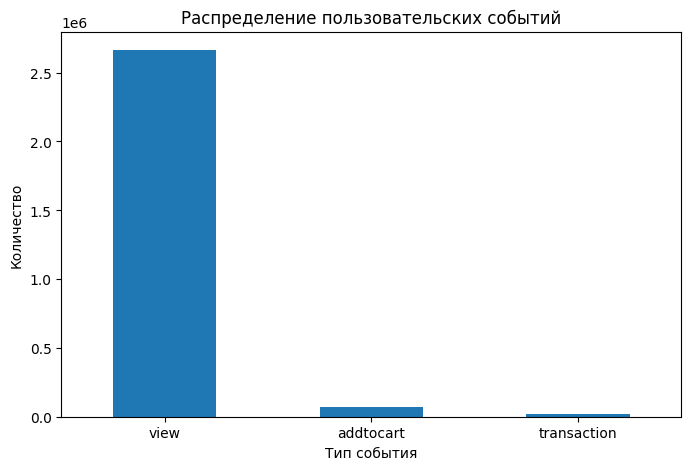

In [45]:
event_counts = (
    events["event"]
    .value_counts()
)

event_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Тип события")
plt.ylabel("Количество")
plt.title("Распределение пользовательских событий")
plt.xticks(rotation=0)
plt.show()

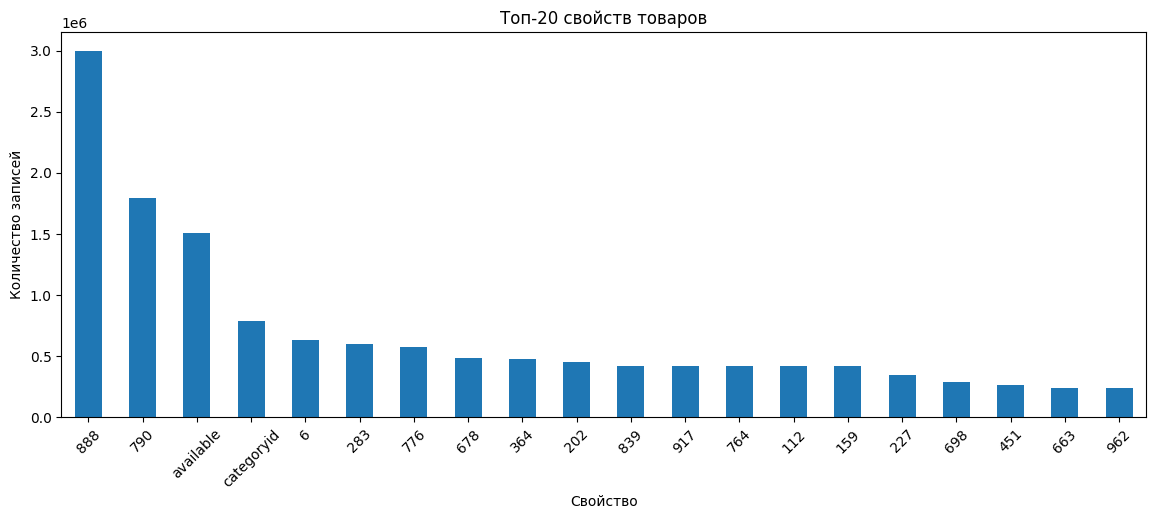

In [46]:
top_properties = (
    item_properties_part["property"]
    .value_counts()
    .head(20)
)

top_properties.plot(
    kind="bar",
    figsize=(14, 5)
)

plt.xlabel("Свойство")
plt.ylabel("Количество записей")
plt.title("Топ-20 свойств товаров")
plt.xticks(rotation=45)
plt.show()

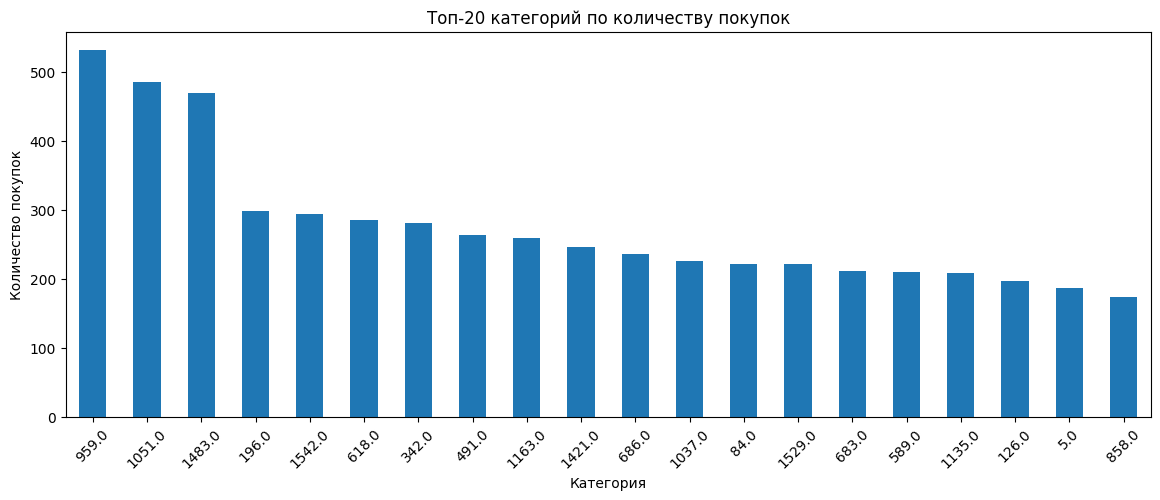

In [47]:
latest_item_categories = (
    item_categories
    .sort_values("timestamp")
    .drop_duplicates("itemid", keep="last")
)
item_to_category = (
    latest_item_categories[
        ["itemid", "categoryid"]
    ]
)

events_with_category = events.merge(
    item_to_category,
    on="itemid",
    how="left"
)
top_transaction_categories = (
    events_with_category[
        events_with_category["event"] == "transaction"
    ]
    .groupby("categoryid")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

top_transaction_categories.plot(
    kind="bar",
    figsize=(14, 5)
)

plt.xlabel("Категория")
plt.ylabel("Количество покупок")
plt.title("Топ-20 категорий по количеству покупок")
plt.xticks(rotation=45)
plt.show()

In [48]:
category_events = (
    events_with_category
    .groupby(["categoryid", "event"])
    .size()
    .unstack(fill_value=0)
)

category_events["total"] = (
    category_events.sum(axis=1)
)

category_events = (
    category_events
    .sort_values("transaction", ascending=False)
)

/tmp/ipykernel_2910/1242632833.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["categoryid", "event"])


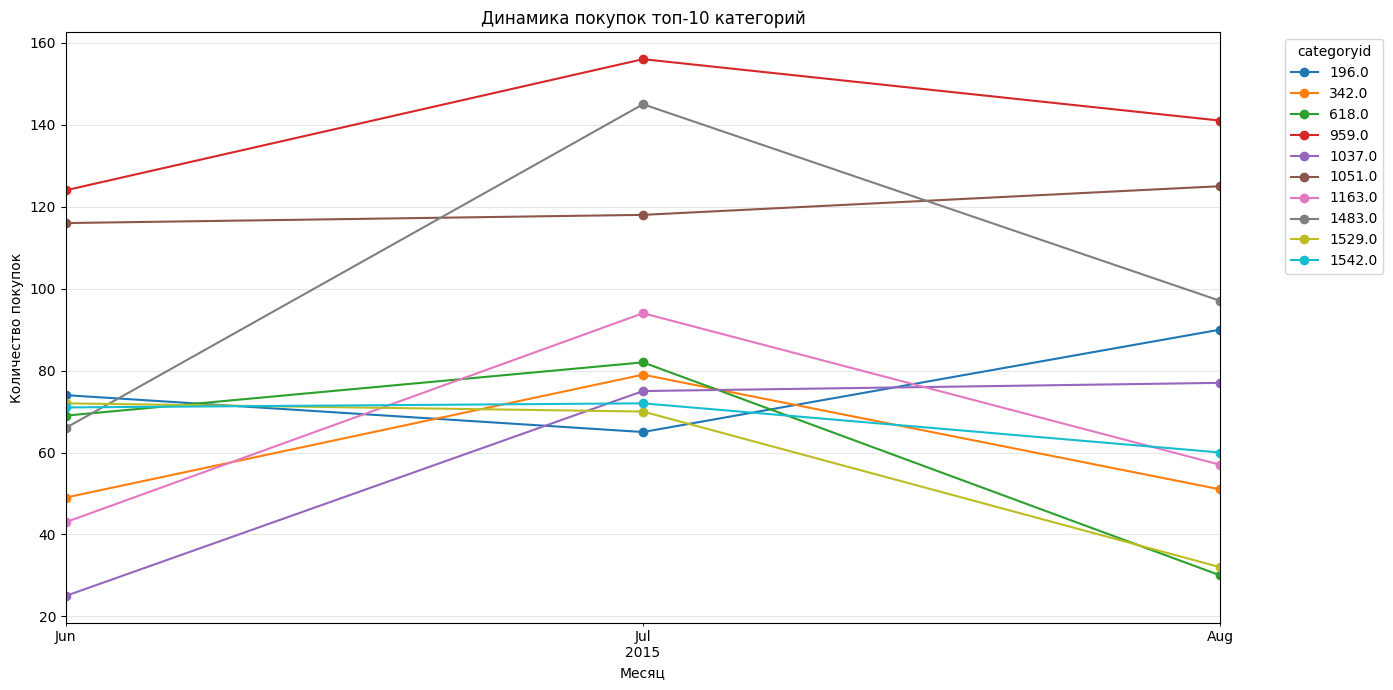

In [49]:
# Оставляем только полные месяцы
events_with_category_time = events_with_category[
    (events_with_category["timestamp"] >= "2015-06-01") &
    (events_with_category["timestamp"] < "2015-09-01")
].copy()

# Только покупки
transactions = events_with_category_time[
    events_with_category_time["event"] == "transaction"
].copy()

# Топ-10 категорий по количеству покупок
# только за полные месяцы
top_10_category_ids = (
    transactions
    .groupby("categoryid")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Оставляем только топ-10 категорий
transactions_top = transactions[
    transactions["categoryid"].isin(top_10_category_ids)
]

# Количество покупок по месяцам и категориям
transactions_by_month_category = (
    transactions_top
    .groupby([
        transactions_top["timestamp"].dt.to_period("M"),
        "categoryid"
    ])
    .size()
    .unstack(fill_value=0)
)

# График
transactions_by_month_category.plot(
    kind="line",
    marker="o",
    figsize=(14, 7)
)

plt.xlabel("Месяц")
plt.ylabel("Количество покупок")
plt.title("Динамика покупок топ-10 категорий")

plt.legend(
    title="categoryid",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
category_events["addtocart_to_view"] = (
    category_events["addtocart"]
    / category_events["view"]
)

category_conversion = (
    category_events[
        category_events["view"] >= 5000
    ]
    .copy()
)

category_conversion["addtocart_to_view_percent"] = (
    category_conversion["addtocart_to_view"] * 100
)

category_conversion = (
    category_conversion
    .sort_values(
        "addtocart_to_view_percent",
        ascending=False
    )
)

top_20_conversion = (
    category_conversion
    .head(20)
    .copy()
)

In [51]:
top_20_conversion[
    [
        "view",
        "addtocart",
        "transaction",
        "addtocart_to_view_percent"
    ]
].style.background_gradient(
    subset=["addtocart_to_view_percent"]
)

event,view,addtocart,transaction,addtocart_to_view_percent
categoryid,,,,
1037.000000,5190,658,226,12.678227
624.000000,5044,431,144,8.544806
686.000000,6052,426,236,7.038995
1.000000,5847,392,80,6.704293
1421.000000,9376,615,246,6.559300
858.000000,13919,759,174,5.452978
1163.000000,7157,374,259,5.225653
1542.000000,12853,668,294,5.197230
1317.000000,6170,303,125,4.910859


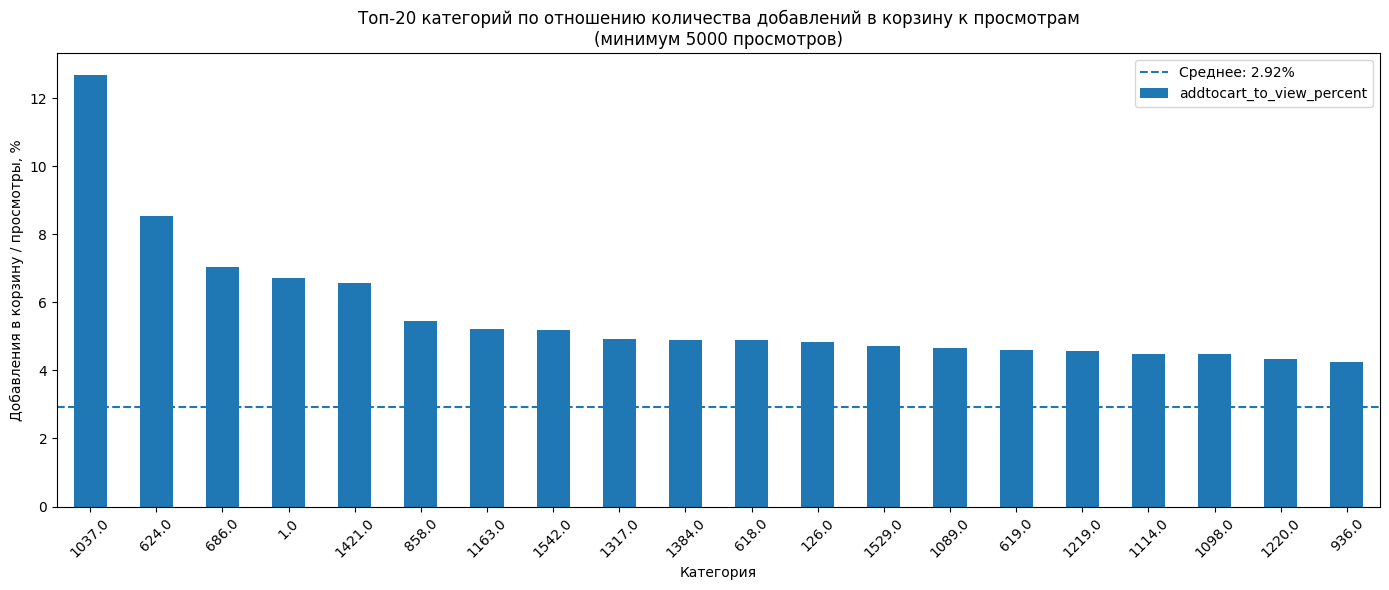

In [52]:
mean_conversion = (
    category_conversion["addtocart_to_view"].mean()
    * 100
)

top_20_conversion[
    "addtocart_to_view_percent"
].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.axhline(
    mean_conversion,
    linestyle="--",
    label=f"Среднее: {mean_conversion:.2f}%"
)

plt.xlabel("Категория")
plt.ylabel("Добавления в корзину / просмотры, %")

plt.title(
    "Топ-20 категорий по отношению количества добавлений в корзину к просмотрам\n"
    "(минимум 5000 просмотров)"
)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# отношение добавлений в корзину к просмотрам
category_events["addtocart_to_view"] = (
    category_events["addtocart"]
    / category_events["view"]
)

# категории минимум с 5000 просмотров
cart_from_view = (
    category_events[
        (category_events["view"] >= 5000)
        & (category_events["addtocart"] > 0)
    ]
    .copy()
)

cart_from_view["addtocart_to_view_percent"] = (
    cart_from_view["addtocart_to_view"] * 100
)

# топ-20
top_20_cart_from_view = (
    cart_from_view
    .sort_values(
        "addtocart_to_view_percent",
        ascending=False
    )
    .head(20)
)

top_20_cart_from_view[
    [
        "view",
        "addtocart",
        "transaction",
        "addtocart_to_view_percent"
    ]
]

event,view,addtocart,transaction,addtocart_to_view_percent
categoryid,,,,
1037.0,5190,658,226,12.678227
624.0,5044,431,144,8.544806
686.0,6052,426,236,7.038995
1.0,5847,392,80,6.704293
1421.0,9376,615,246,6.559300
858.0,13919,759,174,5.452978
1163.0,7157,374,259,5.225653
1542.0,12853,668,294,5.197230
1317.0,6170,303,125,4.910859


In [54]:
overall_cart_to_view = (
    cart_from_view["addtocart"].sum()
    / cart_from_view["view"].sum()
    * 100
)

print(
    f"Общее отношение добавлений в корзину к просмотрам: "
    f"{overall_cart_to_view:.2f}%"
)

Общее отношение добавлений в корзину к просмотрам: 2.77%


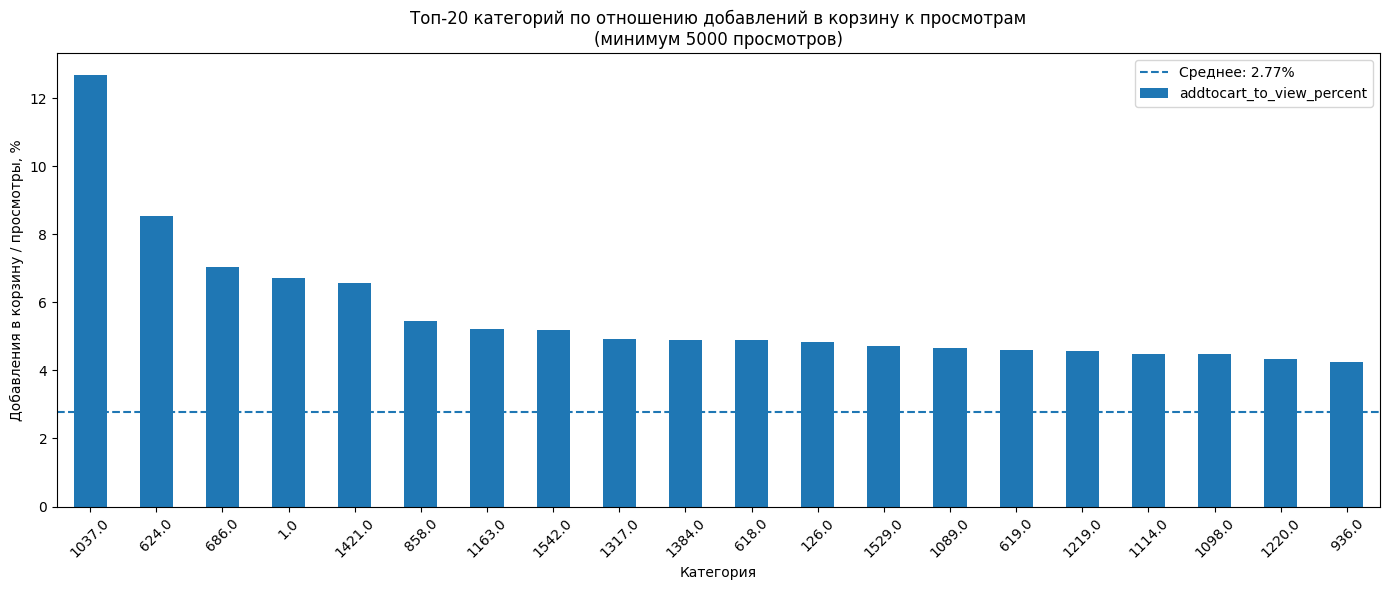

In [55]:
top_20_cart_from_view[
    "addtocart_to_view_percent"
].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.axhline(
    overall_cart_to_view,
    linestyle="--",
    label=f"Среднее: {overall_cart_to_view:.2f}%"
)

plt.xlabel("Категория")
plt.ylabel("Добавления в корзину / просмотры, %")

plt.title(
    "Топ-20 категорий по отношению добавлений в корзину к просмотрам\n"
    "(минимум 5000 просмотров)"
)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
category_events["transaction_to_cart"] = (
    category_events["transaction"]
    / category_events["addtocart"]
)

# минимум 200 добавлений в корзину
purchase_from_cart = (
    category_events[
        (category_events["addtocart"] >= 200)
        & (category_events["transaction"] > 0)
    ]
    .copy()
)

purchase_from_cart["transaction_to_cart_percent"] = (
    purchase_from_cart["transaction_to_cart"] * 100
)

top_20_purchase_from_cart = (
    purchase_from_cart
    .sort_values(
        "transaction_to_cart_percent",
        ascending=False
    )
    .head(20)
)

top_20_purchase_from_cart[
    [
        "view",
        "addtocart",
        "transaction",
        "transaction_to_cart_percent"
    ]
]

event,view,addtocart,transaction,transaction_to_cart_percent
categoryid,,,,
1163.0,7157,374,259,69.251337
686.0,6052,426,236,55.399061
1529.0,9174,432,221,51.157407
1349.0,5863,221,112,50.678733
928.0,11036,301,146,48.504983
209.0,13781,267,119,44.569288
1542.0,12853,668,294,44.011976
175.0,6457,204,88,43.137255
1244.0,10252,285,119,41.754386


In [57]:
overall_transaction_to_cart = (
    purchase_from_cart["transaction"].sum()
    / purchase_from_cart["addtocart"].sum()
    * 100
)

print(
    f"Общее отношение покупок к добавлениям в корзину: "
    f"{overall_transaction_to_cart:.2f}%"
)

Общее отношение покупок к добавлениям в корзину: 30.29%


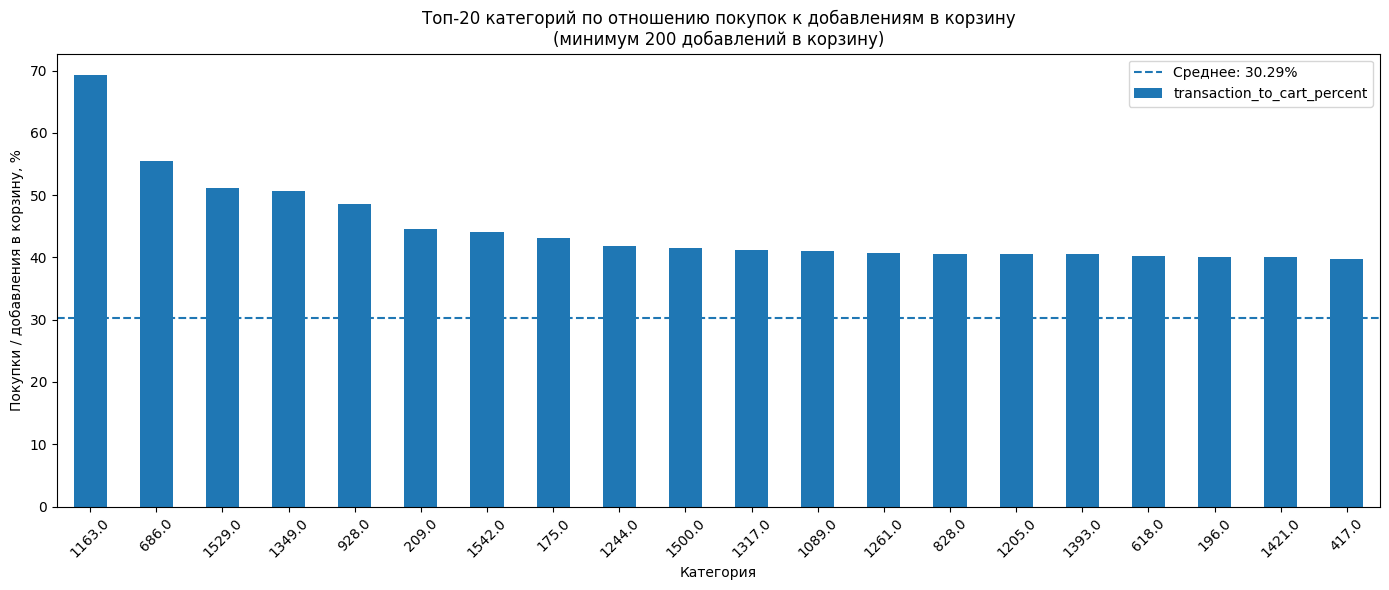

In [58]:
top_20_purchase_from_cart[
    "transaction_to_cart_percent"
].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.axhline(
    overall_transaction_to_cart,
    linestyle="--",
    label=f"Среднее: {overall_transaction_to_cart:.2f}%"
)

plt.xlabel("Категория")
plt.ylabel("Покупки / добавления в корзину, %")

plt.title(
    "Топ-20 категорий по отношению покупок к добавлениям в корзину\n"
    "(минимум 200 добавлений в корзину)"
)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Итоговые выводы по EDA

В ходе исследовательского анализа были рассмотрены временной диапазон данных,
структура свойств товаров, полнота информации о товарах, распределение
пользовательских событий, динамика активности и различия между товарными
категориями.

### Временной диапазон данных

Данные о свойствах товаров охватывают период с **10 мая 2015 года по
13 сентября 2015 года**.

Поскольку май и сентябрь представлены не полностью, для непосредственного
сравнения абсолютных месячных показателей использовались только три полных
месяца:

- июнь 2015;
- июль 2015;
- август 2015.

Для анализов, не связанных с непосредственным сравнением месяцев, использовался
весь доступный временной период.

### Динамика количества товаров

Количество уникальных товаров, для которых зафиксированы записи об изменении
свойств, составляет:

- июнь — 406 953;
- июль — 254 294;
- август — 371 418.

Наибольшее количество товаров с зарегистрированными свойствами наблюдается
в июне, в июле показатель заметно снижается, после чего в августе снова
возрастает.

При этом таблица `item_properties` содержит историю изменений свойств.
Поэтому отсутствие записи о товаре в конкретном месяце не означает, что товар
отсутствовал в каталоге: его свойства могли просто не изменяться в этот период.

### Структура свойств товаров

В таблице свойств содержится **1104 уникальных значения `property`** при более
чем 20 млн записей. Распределение свойств сильно неравномерно: небольшая группа
свойств встречается значительно чаще остальных.

Анализ охвата и количества уникальных значений показал, что свойства имеют
разную природу.

Свойства `159`, `112` и `764`:

- присутствуют у 100% товаров;
- имеют только одно уникальное значение.

Следовательно, эти признаки являются константными и не позволяют различать
товары. Они не несут полезной информации для модели и могут быть исключены
при дальнейшей подготовке признаков.

Признак `available` также присутствует у всех товаров, но содержит два
уникальных значения, поэтому является потенциально полезным бинарным
признаком.

`categoryid` имеет полное покрытие товаров и содержит 1242 уникальных значения,
поэтому категория товара является одним из наиболее информативных
категориальных признаков для дальнейшего построения рекомендаций.

Некоторые обезличенные свойства обладают очень высокой кардинальностью.
Например, для свойств `283`, `888`, `364`, `917`, `202` и `776` количество
различных значений достигает сотен тысяч.

Дополнительный анализ показал, что часть таких свойств является многозначной:
в одном поле `value` может храниться несколько закодированных значений,
разделённых пробелами. Поэтому высокая кардинальность в данном случае может
быть связана не только с разнообразием отдельных характеристик, но и с большим
количеством их комбинаций.

Такие признаки требуют дополнительной обработки перед использованием в модели
и не должны автоматически интерпретироваться как обычные категориальные
признаки.

### Полнота информации о свойствах товаров

В существующих строках таблицы `item_properties` пропуски в полях `property`
и `value` отсутствуют.

Однако между таблицей пользовательских событий и таблицей свойств обнаружена
неполная согласованность.

В `events` присутствует **235 061 уникальный товар**. Из них:

- для **185 246 товаров** информация о свойствах присутствует;
- для **49 815 товаров** информация о свойствах полностью отсутствует.

Таким образом, примерно **21,2% товаров, встречающихся в пользовательских
событиях, отсутствуют в таблице свойств**.

Эти товары не следует автоматически удалять из `events`, поскольку их
взаимодействия остаются полезными для коллаборативных рекомендательных методов,
например ALS.

При дальнейшем формировании товарных признаков отсутствие свойств необходимо
обрабатывать отдельно, например с помощью специальных значений для неизвестных
характеристик или признака наличия информации о товаре.

### Распределение пользовательских событий

За весь доступный период зарегистрировано три типа взаимодействий:

- `view` — 2 664 312;
- `addtocart` — 69 332;
- `transaction` — 22 457.

Распределение сильно несбалансировано: основную часть взаимодействий составляют
просмотры, тогда как добавления в корзину и покупки встречаются значительно
реже.

Для рекомендательной системы эти события можно рассматривать как сигналы
разной силы пользовательского интереса:

`view → addtocart → transaction`

Просмотр является наиболее слабым сигналом интереса, добавление товара в
корзину — более сильным, а покупка — наиболее сильным положительным сигналом.

### Динамика пользовательской активности

При сравнении трёх полных месяцев максимальная активность наблюдается в июле.

Количество взаимодействий:

- июнь — 610 393;
- июль — 697 984;
- август — 553 362.

Количество уникальных пользователей:

- июнь — 313 832;
- июль — 377 199;
- август — 311 128.

Среднее количество взаимодействий на одного уникального пользователя
постепенно снижается:

- июнь — около 1,94;
- июль — около 1,85;
- август — около 1,78.

Таким образом, рост общего числа взаимодействий в июле связан прежде всего
с увеличением количества активных пользователей, тогда как средняя
интенсивность взаимодействий одного пользователя постепенно уменьшается.

### Популярность товарных категорий

Категории существенно различаются по количеству просмотров, добавлений
в корзину и покупок.

По абсолютному количеству покупок среди наиболее популярных категорий
выделяются:

- категория `959` — 532 покупки;
- категория `1051` — 485 покупок;
- категория `1483` — 469 покупок.

При этом большое количество просмотров не обязательно приводит к большему
количеству более сильных взаимодействий.

Поэтому абсолютная популярность категории рассматривалась совместно с
отношениями между различными типами событий.

### Отношение просмотров к добавлениям в корзину

Для категорий с количеством просмотров не менее 5000 было рассчитано отношение:

`addtocart / view`

Общее отношение количества добавлений в корзину к количеству просмотров среди
отобранных категорий составляет около **2,77%**.

Наиболее высокие значения наблюдаются у категорий:

- `1037` — 12,68%;
- `624` — 8,54%;
- `686` — 7,04%;
- `1` — 6,70%;
- `1421` — 6,56%.

Это показывает, что категории существенно различаются не только по общему
количеству просмотров, но и по тому, насколько часто просмотр сопровождается
более сильным сигналом интереса — добавлением товара в корзину.

### Отношение добавлений в корзину к покупкам

Для категорий минимум с 200 добавлениями в корзину было рассчитано отношение:

`transaction / addtocart`

Общее отношение количества покупок к количеству добавлений в корзину составляет
около **30,29%**.

Наиболее высокие значения наблюдаются у категорий:

- `1163` — 69,25%;
- `686` — 55,40%;
- `1529` — 51,16%;
- `1349` — 50,68%;
- `928` — 48,50%.

При этом данные показатели являются отношениями агрегированных количеств
событий. Они не означают, что соответствующая доля конкретных добавлений
в корзину обязательно завершилась покупкой.

Для анализа реальной пользовательской воронки необходимо отдельно отслеживать
последовательность событий на уровне пары `visitorid + itemid`.

## Общий вывод

EDA показал выраженную неоднородность данных как по пользовательским событиям,
так и по характеристикам товаров.

Пользовательские взаимодействия сильно несбалансированы: просмотры значительно
преобладают над добавлениями в корзину и покупками. Поэтому при построении
implicit-feedback модели имеет смысл учитывать различную силу событий
`view`, `addtocart` и `transaction`, например назначая им разные веса.

Категория товара является перспективным дополнительным признаком: она
представлена для всех товаров из таблицы свойств и связана с заметными
различиями в структуре пользовательской активности.

При этом свойства товаров требуют предварительной фильтрации и обработки.
Константные признаки не несут различающей информации, а высококардинальные
и многозначные свойства нельзя напрямую интерпретировать как обычные
категориальные признаки.

Отдельно необходимо учитывать неполное покрытие товаров метаданными:
примерно 21,2% товаров из `events` полностью отсутствуют в таблице свойств.
Удалять такие товары из пользовательских взаимодействий нецелесообразно,
поскольку они всё равно могут участвовать в коллаборативной модели.
Отсутствующие товарные признаки необходимо обрабатывать уже на этапе
feature engineering.

Полученные результаты подтверждают целесообразность комбинированного подхода:
пользовательские взаимодействия могут использоваться для построения
коллаборативных рекомендаций, а категория и другие подходящие характеристики
товаров — как дополнительные признаки при последующем ранжировании.

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

<div style="
    background-color: white;
    color: #d4a900;
    padding: 10px;
    border-radius: 10px;
">
Команда <b>htop</b> выводит количество используемой оперативной памяти.
</div>

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [59]:
constant_properties = property_stats[
    (property_stats["coverage_percent"] == 100)
    & (property_stats["unique_values"] == 1)
].index

constant_properties

CategoricalIndex(['159', '112', '764'], categories=['0', '1', '10', '100', ..., '998', '999', 'available', 'categoryid'], ordered=False, dtype='category', name='property')

In [60]:
item_properties_filtered = (
    item_properties_part[
        ~item_properties_part["property"].isin(constant_properties)
    ]
    .copy()
)

item_properties_filtered.head()

,timestamp,itemid,property,value
0,2015-06-28 03:00:00,460429,categoryid,1338
1,2015-09-06 03:00:00,206783,888,1116713 960601 n277.200
2,2015-08-09 03:00:00,395014,400,n552.000 639502 n720.000 424566
3,2015-05-10 03:00:00,59481,790,n15360.000
4,2015-05-17 03:00:00,156781,917,828513


In [61]:
item_properties_filtered["property"].isin(
    constant_properties
).sum()

0

In [62]:
print("До:", len(item_properties_part))
print("После:", len(item_properties_filtered))
print(
    "Удалено:",
    len(item_properties_part) - len(item_properties_filtered)
)

До: 20275902
После: 19024743
Удалено: 1251159


In [63]:
print(
    "Товаров до:",
    item_properties_part["itemid"].nunique()
)

print(
    "Товаров после:",
    item_properties_filtered["itemid"].nunique()
)

Товаров до: 417053
Товаров после: 417053


In [64]:
print(type(item_properties_filtered.index))

print(
    f"Index memory: "
    f"{item_properties_filtered.index.memory_usage(deep=True) / 1024**3:.2f} GB"
)

<class 'pandas.core.indexes.base.Index'>
Index memory: 0.14 GB


In [65]:
item_properties_filtered.reset_index(
    drop=True,
    inplace=True
)

In [66]:
print(type(item_properties_filtered.index))

print(
    f"Index memory: "
    f"{item_properties_filtered.index.memory_usage(deep=True) / 1024**3:.6f} GB"
)

<class 'pandas.core.indexes.range.RangeIndex'>
Index memory: 0.000000 GB


In [67]:
print(type(events.index))

print(
    f"Index memory: "
    f"{events.index.memory_usage(deep=True) / 1024**3:.2f} GB"
)


<class 'pandas.core.indexes.range.RangeIndex'>
Index memory: 0.00 GB


In [68]:
events = (
    events
    .drop_duplicates()
    .reset_index(drop=True)
)

In [69]:
import os

os.makedirs(
    "parquet_cleaned",
    exist_ok=True
)

events.to_parquet(
    "parquet_cleaned/events.parquet",
    index=False
)

item_properties_filtered.to_parquet(
    "parquet_cleaned/item_properties.parquet",
    index=False
)
category_tree.to_parquet(
    "parquet_cleaned/category_tree.parquet",
    index=False
)

In [70]:
s3.upload_file(
    "parquet_cleaned/events.parquet",
    bucket_name,
    "recsys/data/events.parquet"
)

s3.upload_file(
    "parquet_cleaned/item_properties.parquet",
    bucket_name,
    "recsys/data/item_properties.parquet"
)

s3.upload_file(
    "parquet_cleaned/category_tree.parquet",
    bucket_name,
    "recsys/data/category_tree.parquet"
)

In [71]:
shutil.rmtree(
    "parquet_optimized",
    ignore_errors=True
)

print(
    "parquet_optimized удалён"
)

parquet_optimized удалён


In [1]:
%reset -f

import gc
gc.collect()

0